# Toxic Comment Classification


In this notebook, we study the task of multi-label toxic comment classification and compare three different modeling approaches with increasing levels of model complexity and representation power.

The goal is to predict six toxic categories (`toxic`, `severe_toxic`, `obscene`, `threat`, `insult`, `identity_hate`) for each comment, and evaluate model performance using ROC-AUC metrics.

### Methods Overview

We explore the following three approaches:

1. **NBSVM (Naive Bayes–SVM)**
   - A traditional linear model that combines TF-IDF features with Naive Bayes log-count ratio reweighting.
   - Efficient and strong baseline for text classification.
   - Serves as a high-performance non-neural reference model.

2. **LSTM with GloVe embeddings**
   - A deep learning approach based on bidirectional LSTMs.
   - Uses pre-trained GloVe word embeddings and dropout regularization.
   - Captures sequential and contextual information beyond bag-of-words features.

3. **DistilBERT Transformer fine-tuning**
   - A Transformer-based model leveraging a pre-trained DistilBERT encoder.
   - Fine-tuned end-to-end on the downstream multi-label classification task.
   - Represents the most expressive and modern approach among the three.

### Evaluation Strategy

All models are evaluated on a held-out validation set using:
- Per-label ROC-AUC
- Macro-averaged ROC-AUC
- Micro-averaged ROC-AUC

ROC curves and AUC visualizations are provided to facilitate qualitative comparison across labels and methods.


In [ ]:
import pandas as pd, numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [3]:
train.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [4]:
train['comment_text'][0]

"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27"

In [5]:
lens = train.comment_text.str.len()
lens.mean(), lens.std(), lens.max()

(394.0732213246768, 590.7202819048919, 5000)

### Visualize feature distributions
This line plots histograms for all numerical features in the dataset, helping to quickly inspect data distributions, detect skewness, and identify potential outliers.


<Axes: >

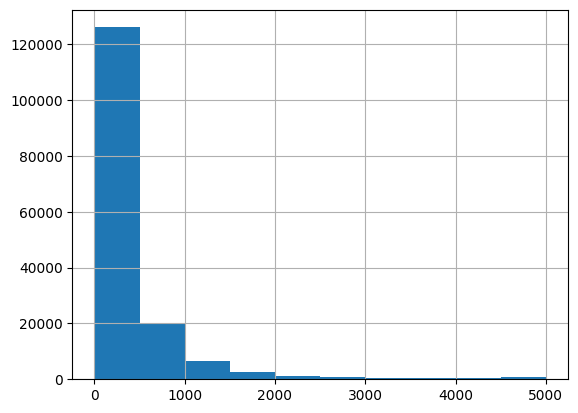

In [6]:
lens.hist()

### Create a "none" label and inspect label statistics
This code defines the list of toxic category labels, creates an additional `none` label for samples that do not belong to any toxic category, and then summarizes the dataset to examine basic statistics of all label columns.


In [7]:
label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
train['none'] = 1-train[label_cols].max(axis=1)
train.describe()

,toxic,severe_toxic,obscene,threat,insult,identity_hate,none
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805,0.898321
std,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420,0.302226
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
len(train),len(test)

(159571, 153164)

In [9]:
COMMENT = 'comment_text'
train[COMMENT].fillna("unknown", inplace=True)
test[COMMENT].fillna("unknown", inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20740\214498403.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test[COMMENT].fillna("unknown", inplace=True)


## 1. NBSVM
This step defines a custom tokenizer used in the first modeling approach (NBSVM).  
It separates punctuation from words to better capture discriminative token-level features, which is especially important for linear models such as Naive Bayes–SVM in text classification tasks.


In [10]:
import re, string
re_tok = re.compile(f'([{string.punctuation}“”¨«»®´·º½¾¿¡§£₤‘’])')
def tokenize(s): return re_tok.sub(r' \1 ', s).split()

### TF-IDF feature extraction
This step converts raw text into TF-IDF features using unigrams and bigrams.  
The customized tokenizer is applied to preserve punctuation information, while frequency thresholds and sublinear TF scaling help reduce noise and improve the effectiveness of linear classifiers such as NBSVM.

In [12]:
n = train.shape[0]
vec = TfidfVectorizer(ngram_range=(1,2), tokenizer=tokenize,
               min_df=3, max_df=0.9, strip_accents='unicode', use_idf=True,
               smooth_idf=True, sublinear_tf=True )
trn_term_doc = vec.fit_transform(train[COMMENT])
test_term_doc = vec.transform(test[COMMENT])

d:\anaconda\envs\wikidemo\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [13]:
trn_term_doc, test_term_doc

(<Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 17775119 stored elements and shape (159571, 426005)>,
 <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 14765768 stored elements and shape (153164, 426005)>)

### Naive Bayes log-count ratio
This step computes class-conditional word statistics used in the Naive Bayes–SVM (NBSVM) approach.  
For each class, it estimates smoothed word frequencies and later enables the calculation of log-count ratios, which reweight TF-IDF features with Naive Bayes priors before feeding them into a linear SVM.


In [14]:
def pr(y_i, y):
    p = x[y==y_i].sum(0)
    return (p+1) / ((y==y_i).sum()+1)
x = trn_term_doc
test_x = test_term_doc

### Model training with NB feature reweighting
This step implements the core of the Naive Bayes–SVM (NBSVM) approach.  
It computes log-count ratios to reweight TF-IDF features using Naive Bayes statistics, then trains a linear classifier (logistic regression) on the transformed feature space to combine generative and discriminative modeling strengths.


In [19]:
def get_mdl(y):
    y = y.values
    r = np.log(pr(1,y) / pr(0,y))
    m = LogisticRegression(C=4, solver='liblinear', dual=True)
    x_nb = x.multiply(r)
    return m.fit(x_nb, y), r

### Validation split, per-label training, and ROC-AUC evaluation
This section creates a stratified train/validation split (based on whether a sample has any toxic label), trains one NBSVM-style classifier per label (one-vs-rest), and evaluates performance using ROC-AUC.  
It reports per-label AUCs, macro/micro AUC summaries, and visualizes results with a bar chart and ROC curves on the validation set.


fit toxic
fit severe_toxic


d:\anaconda\envs\wikidemo\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


fit obscene
fit threat


d:\anaconda\envs\wikidemo\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


fit insult


...

fit identity_hate


d:\anaconda\envs\wikidemo\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



Per-label ROC_AUC:


,label,roc_auc
2,obscene,0.989314
3,threat,0.983439
4,insult,0.982598
1,severe_toxic,0.982585
0,toxic,0.979318
5,identity_hate,0.974901



Macro ROC_AUC (avg over labels): 0.982026
Micro ROC_AUC (flatten all labels): 0.984031


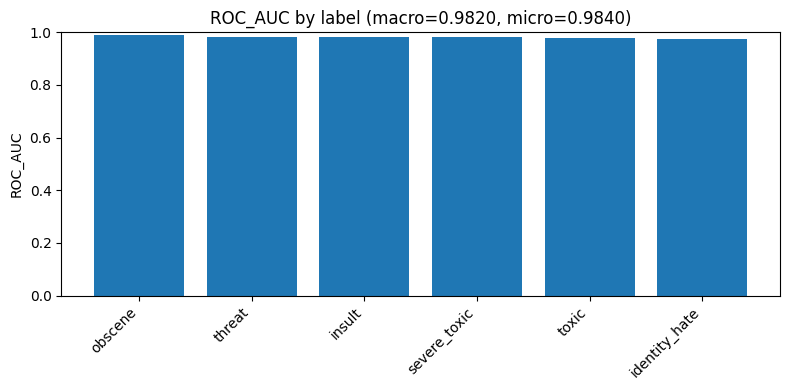

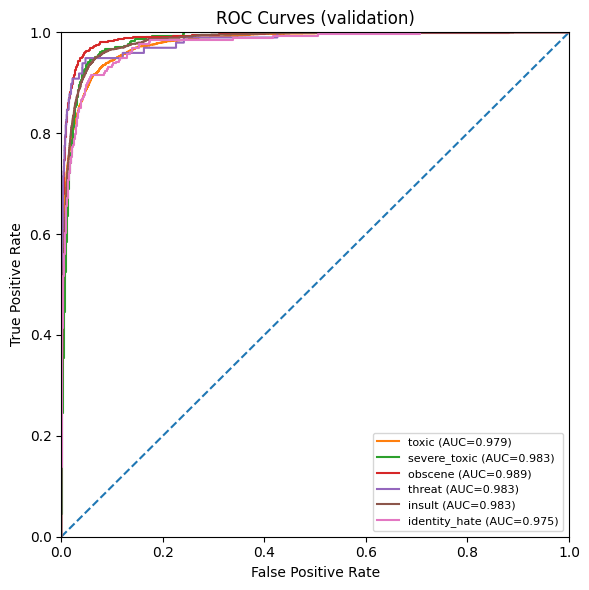

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve


y_any = (train[label_cols].sum(axis=1) > 0).astype(int)

tr_idx, val_idx = train_test_split(
    np.arange(train.shape[0]),
    test_size=0.2,
    random_state=42,
    stratify=y_any
)

X_tr  = x[tr_idx]
X_val = x[val_idx]
y_tr  = train.iloc[tr_idx]
y_val = train.iloc[val_idx]


x_backup = x
x = X_tr

val_preds = np.zeros((X_val.shape[0], len(label_cols)))
aucs = {}
roc_data = {}

for i, col in enumerate(label_cols):
    print("fit", col)
    m, r = get_mdl(y_tr[col]) 
    p = m.predict_proba(X_val.multiply(r))[:, 1]  
    val_preds[:, i] = p

    
    aucs[col] = roc_auc_score(y_val[col].values, p)

    
    fpr, tpr, _ = roc_curve(y_val[col].values, p)
    roc_data[col] = (fpr, tpr)


x = x_backup

auc_df = pd.DataFrame({"label": list(aucs.keys()),
                       "roc_auc": list(aucs.values())}).sort_values("roc_auc", ascending=False)

print("\nPer-label ROC_AUC:")
display(auc_df)


macro_auc = float(auc_df["roc_auc"].mean())
micro_auc = float(roc_auc_score(y_val[label_cols].values.ravel(), val_preds.ravel()))

print(f"\nMacro ROC_AUC (avg over labels): {macro_auc:.6f}")
print(f"Micro ROC_AUC (flatten all labels): {micro_auc:.6f}")

plt.figure(figsize=(8, 4))
plt.bar(auc_df["label"], auc_df["roc_auc"])
plt.ylim(0.0, 1.0)
plt.xticks(rotation=45, ha="right")
plt.ylabel("ROC_AUC")
plt.title(f"ROC_AUC by label (macro={macro_auc:.4f}, micro={micro_auc:.4f})")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle="--")

for col in label_cols:
    fpr, tpr = roc_data[col]
    plt.plot(fpr, tpr, label=f"{col} (AUC={aucs[col]:.3f})")

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (validation)")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## 2. LSTM: GloVe embeddings + dropout regularization
This section sets up the deep learning pipeline for the second approach: a BiLSTM text classifier initialized with pre-trained GloVe word embeddings.  
It uses dropout (and related regularization layers) to reduce overfitting while learning sequence representations for multi-label toxic comment classification.


In [24]:
import sys, os, re, csv, codecs, numpy as np, pandas as pd

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Dense, Input, LSTM, Embedding, Dropout, Activation
from tensorflow.keras.layers import Bidirectional, GlobalMaxPool1D
from tensorflow.keras.models import Model
from tensorflow.keras import initializers, regularizers, constraints, optimizers, layers

In [ ]:
EMBEDDING_FILE=f'glove.6B.50d.txt'
TRAIN_DATA_FILE=f'train.csv'
TEST_DATA_FILE=f'test.csv'
embed_size = 50
max_features = 20000
maxlen = 100
train = pd.read_csv(TRAIN_DATA_FILE)
test = pd.read_csv(TEST_DATA_FILE)

list_sentences_train = train["comment_text"].fillna("_na_").values
list_classes = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
y = train[list_classes].values
list_sentences_test = test["comment_text"].fillna("_na_").values


### Tokenization and sequence padding
This step tokenizes the input text and converts each comment into a fixed-length sequence of word indices.  
Padding and truncation are applied to ensure uniform input shapes for the LSTM model.


In [26]:
tokenizer = Tokenizer(num_words=max_features)
tokenizer.fit_on_texts(list(list_sentences_train))
list_tokenized_train = tokenizer.texts_to_sequences(list_sentences_train)
list_tokenized_test = tokenizer.texts_to_sequences(list_sentences_test)
X_t = pad_sequences(list_tokenized_train, maxlen=maxlen)
X_te = pad_sequences(list_tokenized_test, maxlen=maxlen)

In [27]:
def get_coefs(word,*arr): return word, np.asarray(arr, dtype='float32')
embeddings_index = dict(get_coefs(*o.strip().split()) for o in open(EMBEDDING_FILE))

In [29]:
all_embs = np.stack(list(embeddings_index.values()))
emb_mean,emb_std = all_embs.mean(), all_embs.std()
emb_mean,emb_std

(0.020940498, 0.6441043)

### GloVe embedding matrix initialization
This step constructs the embedding matrix for the LSTM model.  
Pre-trained GloVe vectors are used to initialize word embeddings when available, while the remaining entries are randomly initialized to match the embedding distribution.


In [30]:
word_index = tokenizer.word_index
nb_words = min(max_features, len(word_index))
embedding_matrix = np.random.normal(emb_mean, emb_std, (nb_words, embed_size))
for word, i in word_index.items():
    if i >= max_features: continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None: embedding_matrix[i] = embedding_vector

### BiLSTM architecture with GloVe and dropout
This step defines the neural network architecture for the LSTM-based classifier.  
It uses pre-trained GloVe embeddings as input, a bidirectional LSTM to capture contextual information, global max pooling for sequence aggregation, and dropout-regularized dense layers for multi-label prediction.


In [31]:
inp = Input(shape=(maxlen,))
x = Embedding(max_features, embed_size, weights=[embedding_matrix])(inp)
x = Bidirectional(LSTM(50, return_sequences=True, dropout=0.1, recurrent_dropout=0.1))(x)
x = GlobalMaxPool1D()(x)
x = Dense(50, activation="relu")(x)
x = Dropout(0.1)(x)
x = Dense(6, activation="sigmoid")(x)
model = Model(inputs=inp, outputs=x)
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

### Train/validation split, training, and ROC-AUC evaluation
This section creates a stratified train/validation split (based on whether a sample has any positive label), trains the BiLSTM model, and evaluates its multi-label performance using ROC-AUC.  
It reports per-label AUCs as well as macro/micro AUC summaries, and visualizes results with a bar chart and ROC curves on the validation set.


Epoch 1/2
4488/4488 ━━━━━━━━━━━━━━━━━━━━ 373s 83ms/step - accuracy: 0.9608 - loss: 0.0404 - val_accuracy: 0.9937 - val_loss: 0.0398
Epoch 2/2
4488/4488 ━━━━━━━━━━━━━━━━━━━━ 387s 86ms/step - accuracy: 0.9399 - loss: 0.0373 - val_accuracy: 0.9937 - val_loss: 0.0418
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 176ms/step

Per-label ROC_AUC:


,label,roc_auc
2,obscene,0.992243
3,threat,0.990964
1,severe_toxic,0.988529
4,insult,0.986859
0,toxic,0.981615
5,identity_hate,0.980173



Macro ROC_AUC (avg over 6 labels): 0.986730
Micro ROC_AUC (flatten all labels): 0.990042


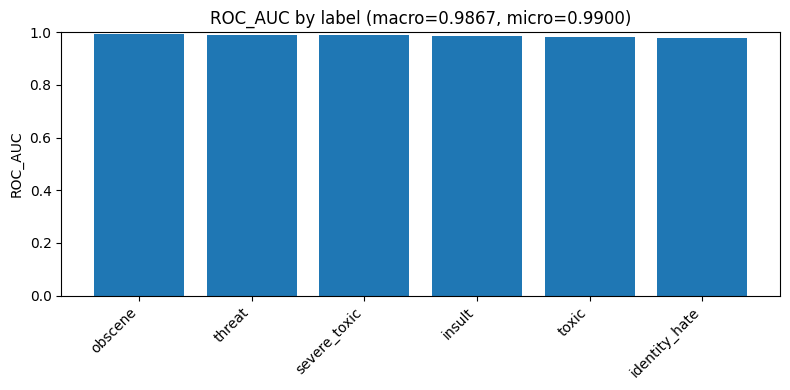

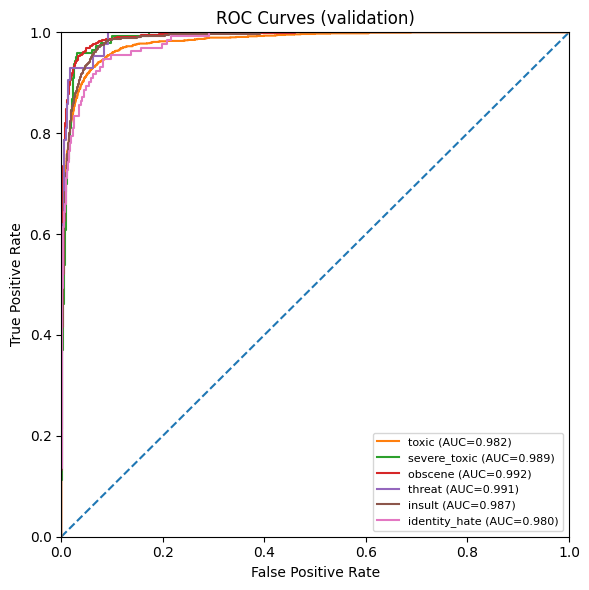

In [34]:
y_any = (y.sum(axis=1) > 0).astype(int)

X_train, X_val, y_train, y_val = train_test_split(
    X_t, y,
    test_size=0.1,
    random_state=42,
    stratify=y_any
)


history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=2,
    validation_data=(X_val, y_val)
)


y_val_pred = model.predict(X_val, batch_size=1024, verbose=1)

aucs = {}
roc_data = {}
for i, cls in enumerate(list_classes):
    aucs[cls] = roc_auc_score(y_val[:, i], y_val_pred[:, i])
    fpr, tpr, _ = roc_curve(y_val[:, i], y_val_pred[:, i])
    roc_data[cls] = (fpr, tpr)

auc_df = pd.DataFrame({"label": list(aucs.keys()), "roc_auc": list(aucs.values())}) \
          .sort_values("roc_auc", ascending=False)

print("\nPer-label ROC_AUC:")
display(auc_df)

macro_auc = float(np.mean(list(aucs.values())))
micro_auc = float(roc_auc_score(y_val.ravel(), y_val_pred.ravel()))

print(f"\nMacro ROC_AUC (avg over 6 labels): {macro_auc:.6f}")
print(f"Micro ROC_AUC (flatten all labels): {micro_auc:.6f}")

plt.figure(figsize=(8, 4))
plt.bar(auc_df["label"], auc_df["roc_auc"])
plt.ylim(0.0, 1.0)
plt.xticks(rotation=45, ha="right")
plt.ylabel("ROC_AUC")
plt.title(f"ROC_AUC by label (macro={macro_auc:.4f}, micro={micro_auc:.4f})")
plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle="--") 

for cls in list_classes:
    fpr, tpr = roc_data[cls]
    plt.plot(fpr, tpr, label=f"{cls} (AUC={aucs[cls]:.3f})")

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (validation)")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## 3. DistilBERT: Transformer fine-tuning
This section sets up the Transformer-based approach using DistilBERT.  
We load the required PyTorch and Hugging Face Transformers components to tokenize text, build datasets/dataloaders, and fine-tune a DistilBERT model for multi-label classification.


In [25]:
import pandas as pd
import torch
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader, RandomSampler, SequentialSampler
from transformers import DistilBertTokenizer, DistilBertModel

In [26]:
MAX_LEN = 128
TRAIN_BATCH_SIZE = 4
VALID_BATCH_SIZE = 4
EPOCHS = 1
LEARNING_RATE = 1e-05
DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(DEVICE)

cpu


In [27]:
train_data = pd.read_csv('train.csv')

label_columns = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
train_data['labels'] = train_data[label_columns].apply(lambda x: list(x), axis=1)

train_data.drop(['id'], inplace=True, axis=1)
train_data.drop(label_columns, inplace=True, axis=1)


### Custom PyTorch dataset for multi-label text classification
This step defines a custom `Dataset` class that prepares inputs for DistilBERT.  
It handles text cleaning, tokenization, attention masks, and (when available) multi-label targets, enabling efficient batching and training/inference with PyTorch DataLoaders.


In [28]:
class MultiLabelDataset(Dataset):

    def __init__(self, dataframe, tokenizer, max_len, new_data=False):
        self.tokenizer = tokenizer
        self.data = dataframe
        self.text = dataframe.comment_text
        self.new_data = new_data
        
        if not new_data:
            self.targets = self.data.labels
        self.max_len = max_len

    def __len__(self):
        return len(self.text)

    def __getitem__(self, index):
        text = str(self.text[index])
        text = " ".join(text.split())

        inputs = self.tokenizer.encode_plus(
            text,
            None,
            add_special_tokens=True,
            max_length=self.max_len,
            pad_to_max_length=True,
            return_token_type_ids=True
        )
        ids = inputs['input_ids']
        mask = inputs['attention_mask']
        token_type_ids = inputs["token_type_ids"]

        out = {
            'ids': torch.tensor(ids, dtype=torch.long),
            'mask': torch.tensor(mask, dtype=torch.long),
            'token_type_ids': torch.tensor(token_type_ids, dtype=torch.long),
        }
        
        if not self.new_data:
            out['targets'] = torch.tensor(self.targets[index], dtype=torch.float)

        return out

### Train/validation split and tokenizer initialization
This step splits the labeled dataset into training and validation sets, then initializes the pre-trained DistilBERT tokenizer.  
Custom `MultiLabelDataset` objects are created to prepare batched inputs for fine-tuning and evaluation.


In [ ]:
train_size = 0.9

train_df = train_data.sample(frac=train_size, random_state=123)
val_df = train_data.drop(train_df.index).reset_index(drop=True)
train_df = train_df.reset_index(drop=True)


print("Orig Dataset: {}".format(train_data.shape))
print("Training Dataset: {}".format(train_df.shape))
print("Validation Dataset: {}".format(val_df.shape))

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased', truncation=True, do_lower_case=True)
training_set = MultiLabelDataset(train_df, tokenizer, MAX_LEN)
val_set = MultiLabelDataset(val_df, tokenizer, MAX_LEN)

Orig Dataset: (159571, 2)
Training Dataset: (151592, 2)
Validation Dataset: (7979, 2)


d:\anaconda\envs\wikidemo\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [38]:
train_params = {'batch_size': TRAIN_BATCH_SIZE,
                'shuffle': True,
                'num_workers': 0
                }

val_params = {'batch_size': VALID_BATCH_SIZE,
               'shuffle': False,
               'num_workers': 0
                }

training_loader = DataLoader(training_set, **train_params)
val_loader = DataLoader(val_set, **val_params)

### Classification head and model definition
This step defines the DistilBERT-based neural network for multi-label classification.  
A pre-trained DistilBERT encoder is combined with a custom feed-forward classification head, enabling end-to-end fine-tuning on the toxic comment labels.


In [32]:
class DistilBERTClass(torch.nn.Module):
    def __init__(self):
        super(DistilBERTClass, self).__init__()
        
        self.bert = DistilBertModel.from_pretrained("distilbert-base-uncased")
        self.classifier = torch.nn.Sequential(
            torch.nn.Linear(768, 768),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.1),
            torch.nn.Linear(768, 6)
        )

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        output_1 = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        hidden_state = output_1[0]
        out = hidden_state[:, 0]
        out = self.classifier(out)
        return out

model = DistilBERTClass()
model.to(DEVICE)

DistilBERTClass(
  (bert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): MultiHeadSelfAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1): Linear(

In [33]:
optimizer = torch.optim.Adam(params=model.parameters(), lr=LEARNING_RATE)

### DistilBERT: Fine-tuning loop with BCEWithLogits loss
This section fine-tunes the DistilBERT model on the training set using mini-batch gradient descent.  
Because this is a multi-label task, it applies `binary_cross_entropy_with_logits` (sigmoid + BCE in a numerically stable form), updates parameters with backpropagation, and tracks the running average loss with a tqdm progress bar.


In [ ]:
def train(epoch):
    model.train()
    running_loss = 0.0

    pbar = tqdm(
        training_loader,
        total=len(training_loader),
        desc=f"Epoch {epoch+1}"
    )
    for step, data in enumerate(pbar):
        ids = data['ids'].to(DEVICE, dtype=torch.long)
        mask = data['mask'].to(DEVICE, dtype=torch.long)
        targets = data['targets'].to(DEVICE, dtype=torch.float)

        outputs = model(input_ids=ids, attention_mask=mask)
        
    
        loss = torch.nn.functional.binary_cross_entropy_with_logits(outputs, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        avg_loss = running_loss / (step + 1)

        pbar.set_postfix({
            "loss": f"{avg_loss:.4f}"
        })

    print(f"\nEpoch {epoch+1} finished. Avg loss: {avg_loss:.4f}\n")
for epoch in range(EPOCHS):
    train(epoch)

Epoch 1:   0%|          | 0/31915 [00:00<?, ?it/s]Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
d:\anaconda\envs\wikidemo\lib\site-packages\transformers\tokenization_utils_base.py:2870: FutureWarning: The `pad_to_max_length` argument is deprecated and will be removed in a future version, use `padding=True` or `padding='longest'` to pad to the longest sequence in the batch, or use `padding='max_length'` to pad to a max length. In this case, you can give a specific length with `max_length` (e.g. `max_length=45`) or leave max_length to None to pad to the maximal input size of the model (e.g. 512 for Bert).
  warnings.warn(
Epoch 1:   6%|▋         | 2009/31915 [34:56<8

KeyboardInterrupt: 

### Validation ROC-AUC evaluation and ROC curve visualization
This section defines an evaluation utility for the fine-tuned DistilBERT model.  
It runs inference on the validation DataLoader, applies a sigmoid to convert logits into per-label probabilities, computes per-label ROC-AUC as well as macro/micro averages, and visualizes performance using an AUC bar chart and overlaid ROC curves.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

label_cols = ["toxic","severe_toxic","obscene","threat","insult","identity_hate"]

def eval_and_plot_roc_auc(model, val_loader, label_cols):
    model.eval()
    all_probs = []
    all_true = []

    with torch.inference_mode():
        for _, data in tqdm(enumerate(val_loader, 0), total=len(val_loader)):
            ids  = data["ids"].to(DEVICE, dtype=torch.long)
            mask = data["mask"].to(DEVICE, dtype=torch.long)
            y    = data["targets"].cpu().numpy()

            outputs = model(input_ids=ids, attention_mask=mask)
            logits = outputs.logits if hasattr(outputs, "logits") else outputs
            probs = torch.sigmoid(logits).cpu().numpy()  

            all_true.append(y)
            all_probs.append(probs)

    y_true = np.vstack(all_true)
    y_prob = np.vstack(all_probs)

    aucs = {}
    roc_data = {}
    for i, cls in enumerate(label_cols):
        aucs[cls] = roc_auc_score(y_true[:, i], y_prob[:, i])
        fpr, tpr, _ = roc_curve(y_true[:, i], y_prob[:, i])
        roc_data[cls] = (fpr, tpr)

    macro_auc = float(np.mean(list(aucs.values())))
    micro_auc = float(roc_auc_score(y_true.ravel(), y_prob.ravel()))

    print("Macro ROC_AUC:", macro_auc)
    print("Micro ROC_AUC:", micro_auc)
    for cls in label_cols:
        print(cls, aucs[cls])

    labels_sorted = sorted(aucs.keys(), key=lambda k: aucs[k], reverse=True)
    plt.figure(figsize=(8,4))
    plt.bar(labels_sorted, [aucs[k] for k in labels_sorted])
    plt.ylim(0,1)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("ROC_AUC")
    plt.title(f"ROC_AUC by label (macro={macro_auc:.4f}, micro={micro_auc:.4f})")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,6))
    plt.plot([0,1], [0,1], linestyle="--")
    for cls in label_cols:
        fpr, tpr = roc_data[cls]
        plt.plot(fpr, tpr, label=f"{cls} (AUC={aucs[cls]:.3f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves (validation)")
    plt.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()

    return aucs, macro_auc, micro_auc


100%|██████████| 1995/1995 [08:55<00:00,  3.73it/s]


Macro ROC_AUC: 0.9749115680377232
Micro ROC_AUC: 0.9865580202786464
toxic 0.9776901741211413
severe_toxic 0.9913884762429023
obscene 0.9915236740546859
threat 0.9347662141779789
insult 0.9828709868559378
identity_hate 0.9712298827736936


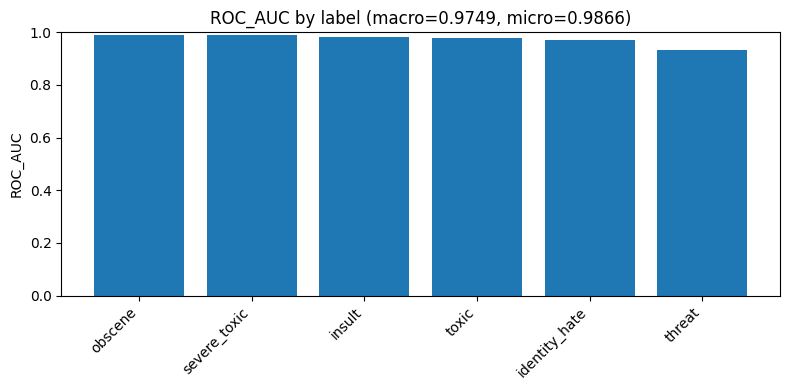

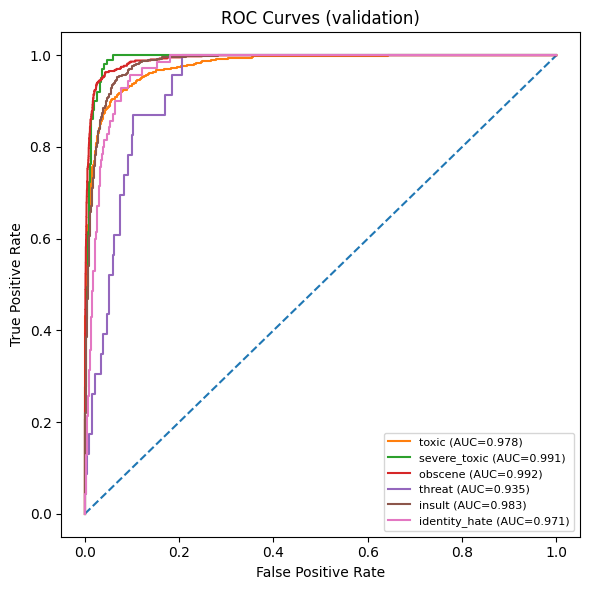

In [39]:
aucs, macro_auc, micro_auc = eval_and_plot_roc_auc(model, val_loader, label_cols)